In [67]:
import numpy as np

In [68]:
circle_center = np.array([0.4, 0.0, 0.45])  # Center of circle on table
circle_radius = 0.15 
circle_drawing = False
circle_start_time = 0
circle_duration = 10.0  # in total 10 seconds to draw circles, after 10s it stops
contact_threshold = 8.0  # Force threshold to start drawing (close to desired 10N)
contact_stable_time = 0
contact_stable_duration = 1.0
angular_speed = np.pi/4

In [69]:
times = []
angles = []
target_positions = []
x_dot_desired_s = []
x_ddot_desired_s = []

In [70]:
elapsed_time = 0
target_pos = np.array([0.4, 0., 0.6])
x_dot_desired = np.array([0., 0., 0.])
x_ddot_desired = np.array([0., 0., 0.])
while elapsed_time < circle_duration:
    angle = (np.pi/4) * np.sin(angular_speed * elapsed_time)
    angle_dot = (np.pi/4) * angular_speed * np.cos(angular_speed * elapsed_time)
    angle_ddot = -(np.pi/4) * angular_speed**2 * np.sin(angular_speed * elapsed_time) 
    target_pos[0] = circle_center[0]
    target_pos[1] = circle_center[1] + circle_radius * np.sin(angle)
    target_pos[2] = circle_center[2] + circle_radius * np.cos(angle)
    x_dot_desired[0] = 0.0
    x_dot_desired[1] = circle_radius * np.cos(angle) * angle_dot
    x_dot_desired[2] = -circle_radius * np.sin(angle) * angle_dot
    # x_ddot
    x_ddot_desired[0] = 0.0
    x_ddot_desired[1] = circle_radius * (
        -np.sin(angle) * angle_dot**2 + np.cos(angle) * angle_ddot
    )
    x_ddot_desired[2] = circle_radius * (
        -np.cos(angle) * angle_dot**2 - np.sin(angle) * angle_ddot
    )
# Store data
    times.append(elapsed_time)
    angles.append(angle)
    target_positions.append(target_pos.copy())
    x_dot_desired_s.append(x_dot_desired.copy())
    x_ddot_desired_s.append(x_ddot_desired.copy())
    elapsed_time += 0.1

elapsed_time = 0

In [71]:
target_positions = np.array(target_positions)
x_ddot_desired_s = np.array(x_ddot_desired_s)
x_dot_desired_s = np.array(x_dot_desired_s)
angles_deg = np.degrees(np.array(angles))

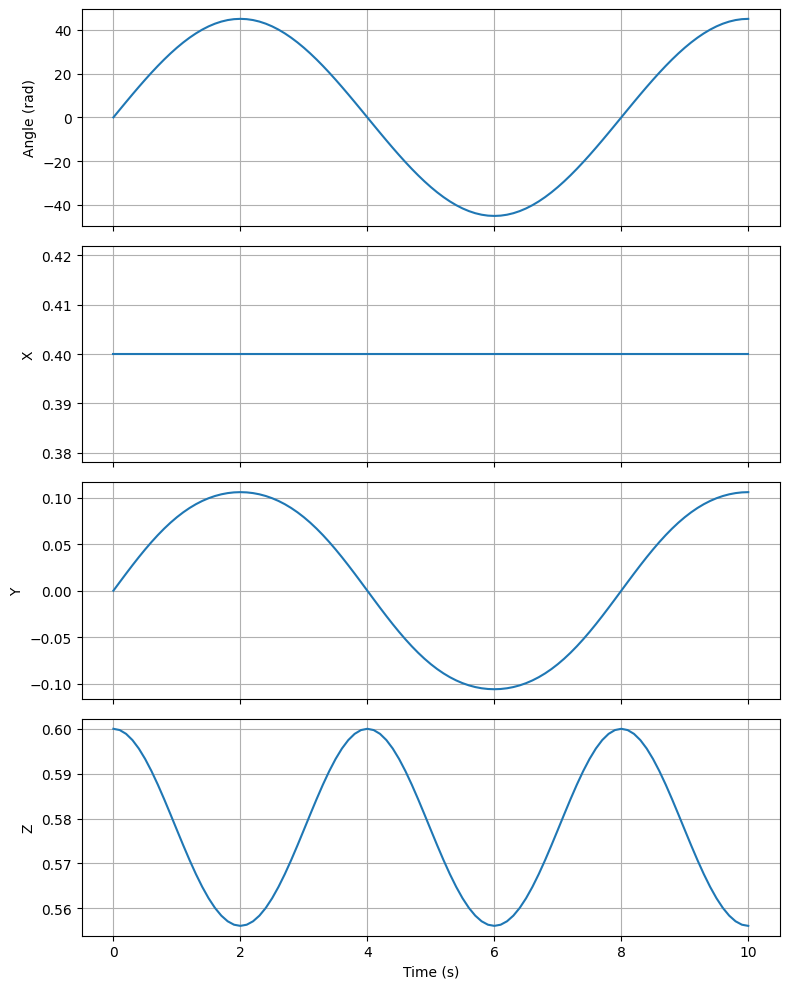

In [72]:
import matplotlib.pyplot as plt
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

axs[0].plot(times, angles_deg)
axs[0].set_ylabel("Angle (rad)")
axs[0].grid(True)

axs[1].plot(times, target_positions[:,0])
axs[1].set_ylabel("X")
axs[1].grid(True)

axs[2].plot(times, target_positions[:,1])
axs[2].set_ylabel("Y")
axs[2].grid(True)

axs[3].plot(times, target_positions[:,2])
axs[3].set_ylabel("Z")
axs[3].set_xlabel("Time (s)")
axs[3].grid(True)

plt.tight_layout()
plt.show()

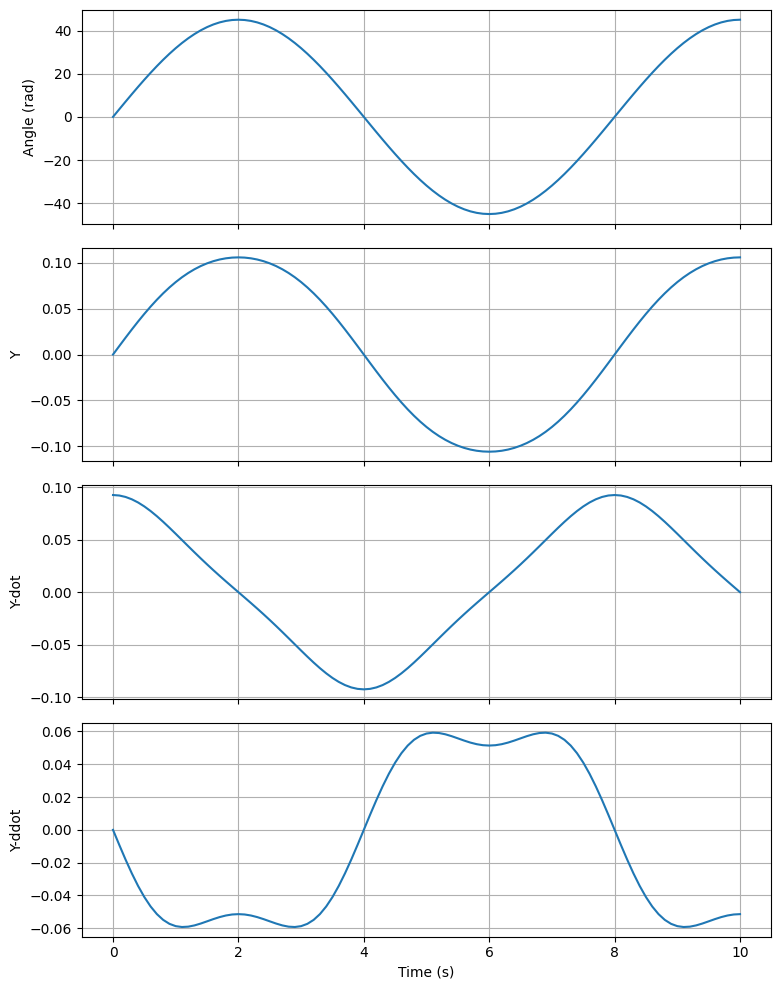

In [73]:
fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

axs[0].plot(times, angles_deg)
axs[0].set_ylabel("Angle (rad)")
axs[0].grid(True)

axs[1].plot(times, target_positions[:,1])
axs[1].set_ylabel("Y")
axs[1].grid(True)

axs[2].plot(times, x_dot_desired_s[:,1])
axs[2].set_ylabel("Y-dot")
axs[2].grid(True)

axs[3].plot(times, x_ddot_desired_s[:,1])
axs[3].set_ylabel("Y-ddot")
axs[3].set_xlabel("Time (s)")
axs[3].grid(True)

plt.tight_layout()
plt.show()

In [19]:
S_v = np.zeros((6, 5))
S_v[0, 0] = 1
S_v[2, 1] = 1
S_v[3, 2] = 1
S_v[4, 3] = 1
S_v[5, 4] = 1

S_v

array([[1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [33]:
thetas = [0, np.pi/4, np.pi/2, np.pi]

In [82]:
theta = -np.pi/4
r = np.array([
        [1, 0, 0],
        [0, np.cos(-theta), -np.sin(-theta)],
        [0, np.sin(-theta), np.cos(-theta)]
    ])
print(r)
r @ np.array([0,1,1]).T

[[ 1.     0.     0.   ]
 [ 0.     0.707 -0.707]
 [ 0.     0.707  0.707]]


array([0.   , 0.   , 1.414])

In [27]:
def get_rotation_m(theta):
    r = np.array([
        [1, 0, 0],
        [0, -np.cos(theta), -np.sin(theta)],
        [0, -np.sin(theta), np.cos(theta)]
    ])
    R = np.zeros((6, 6))
    R[0:3, 0:3] = r
    R[3:6, 3:6] = r
    return R

np.set_printoptions(precision=3)
for t in thetas:
    print(get_rotation_m(t))

[[ 1.  0.  0.  0.  0.  0.]
 [ 0. -1. -0.  0.  0.  0.]
 [ 0. -0.  1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0. -1. -0.]
 [ 0.  0.  0.  0. -0.  1.]]
[[ 1.     0.     0.     0.     0.     0.   ]
 [ 0.    -0.707 -0.707  0.     0.     0.   ]
 [ 0.    -0.707  0.707  0.     0.     0.   ]
 [ 0.     0.     0.     1.     0.     0.   ]
 [ 0.     0.     0.     0.    -0.707 -0.707]
 [ 0.     0.     0.     0.    -0.707  0.707]]
[[ 1.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00 -6.123e-17 -1.000e+00  0.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00 -1.000e+00  6.123e-17  0.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00 -6.123e-17 -1.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00 -1.000e+00  6.123e-17]]
[[ 1.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00  1.000e+00 -1.225e-16  0.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00 

In [84]:
import mujoco

In [88]:
target_quat = np.array([0., 1., 0., 0.])
angle = -np.pi/4

In [89]:
q_rot = np.array([np.cos(angle/2), 0, 0, np.sin(angle/2)], dtype=np.float64)
q_base = np.array([0., 1., 0., 0.])
mujoco.mju_mulQuat(target_quat, q_rot, q_base)
target_quat

array([ 0.   ,  0.924, -0.383,  0.   ])